# ✈️ Flight Data Analysis

In this project I explore a real-world flights dataset to uncover insights 
about delays, cancellations, and airline performance.

**Tools used:** Python, Pandas, Matplotlib, Seaborn

**Dataset:** 2015 Flight Delays and Cancellations (Kaggle)

In [4]:
import pandas as pd

## 1. Loading & Cleaning the Data
First we load the dataset, explore its shape and columns, and remove rows 
with missing delay information.

In [7]:
df = pd.read_csv('flights.csv', low_memory=False)

In [8]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.shape

(5819079, 31)

In [10]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [11]:
df.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [12]:
df = df.dropna(subset=['ARRIVAL_DELAY', 'DEPARTURE_DELAY'])

In [13]:
df.shape

(5714008, 31)

## 2. Which Airline Has the Most Delays?
We calculate the average departure delay in minutes for each airline.

In [19]:
avg_delay = df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False)
print(avg_delay)

AIRLINE
NK    15.883101
UA    14.333056
F9    13.303352
B6    11.442467
WN    10.517183
MQ     9.967187
VX     8.993486
AA     8.826106
EV     8.615598
OO     7.736083
DL     7.313300
US     6.081000
AS     1.718926
HA     0.469918
Name: DEPARTURE_DELAY, dtype: float64


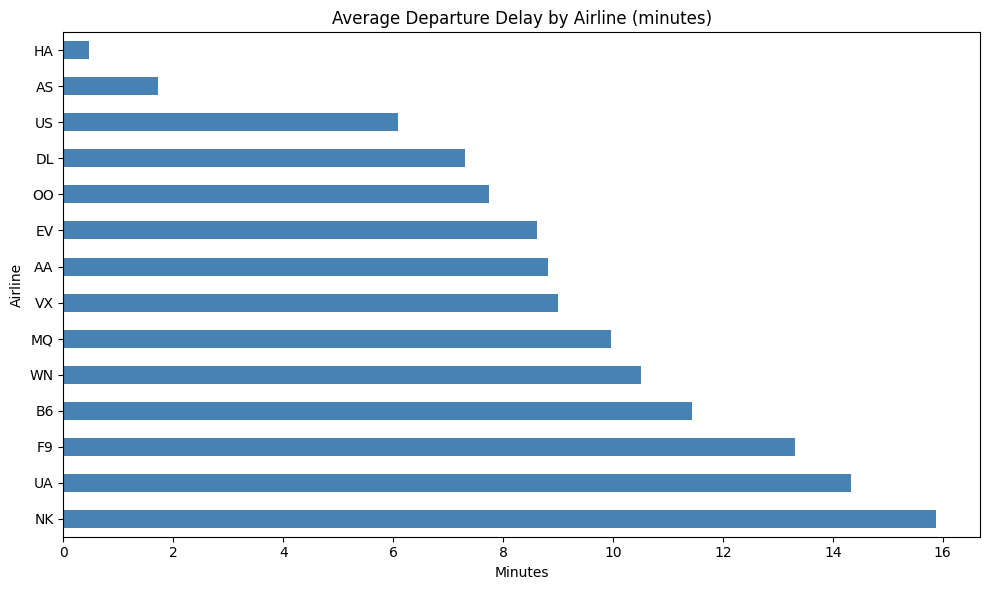

In [38]:
import matplotlib.pyplot as plt

avg_delay.plot(kind='barh', figsize=(10, 6), color='steelblue')

plt.title('Average Departure Delay by Airline (minutes)')
plt.xlabel('Minutes')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

### Key Insight
NK (Spirit Airlines) has the highest average departure delay at ~16 minutes, 
while HA (Hawaiian Airlines) is the most punctual with under 1 minute average delay.

## 3. Which Month is the Worst for Flying?
We group flights by month to find seasonal delay patterns.

In [28]:
avg_delay_month = df.groupby('MONTH')['DEPARTURE_DELAY'].mean().sort_values(ascending=True)
print(avg_delay_month)

MONTH
9      4.796727
10     4.943797
11     6.885799
4      7.629695
5      9.363599
3      9.577377
1      9.689711
8      9.871745
7     11.347285
12    11.687729
2     11.775707
6     13.873827
Name: DEPARTURE_DELAY, dtype: float64


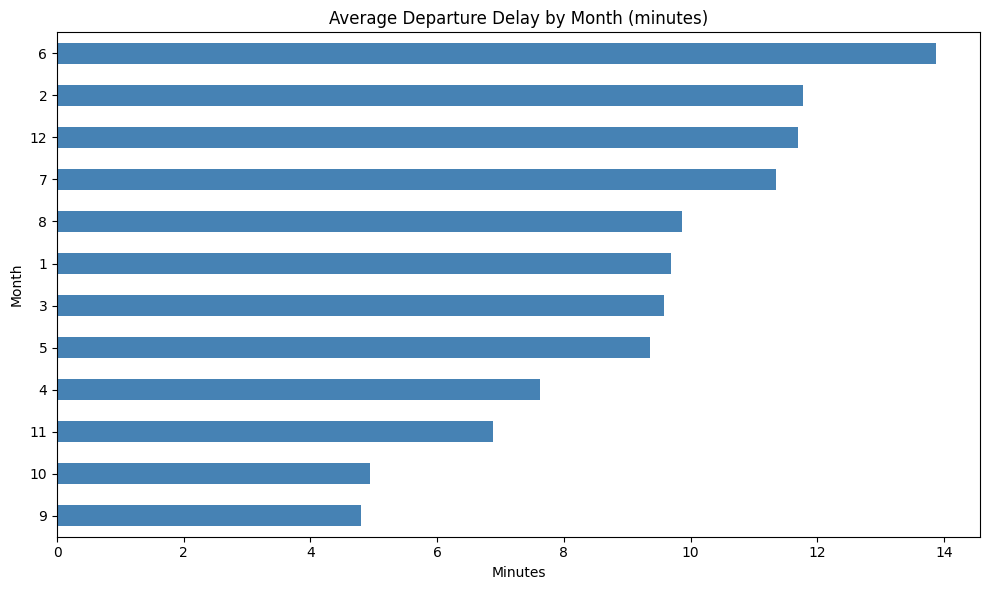

In [29]:
import matplotlib.pyplot as plt

avg_delay_month.plot(kind='barh', figsize=(10, 6), color='steelblue')

plt.title('Average Departure Delay by Month (minutes)')
plt.xlabel('Minutes')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

### Key Insight
June is the worst month for delays with almost 14 minutes average, likely due to 
summer travel demand and storm season. September is the best month to fly.

## 4. Why Do Flights Get Cancelled?
We filter only cancelled flights and break down the reasons.

In [31]:
df_cancelled = pd.read_csv('flights.csv', low_memory=False)
df_cancelled = df_cancelled[df_cancelled['CANCELLED'] == 1]
cancellations = df_cancelled['CANCELLATION_REASON'].value_counts()
print(cancellations)

CANCELLATION_REASON
B    48851
A    25262
C    15749
D       22
Name: count, dtype: int64


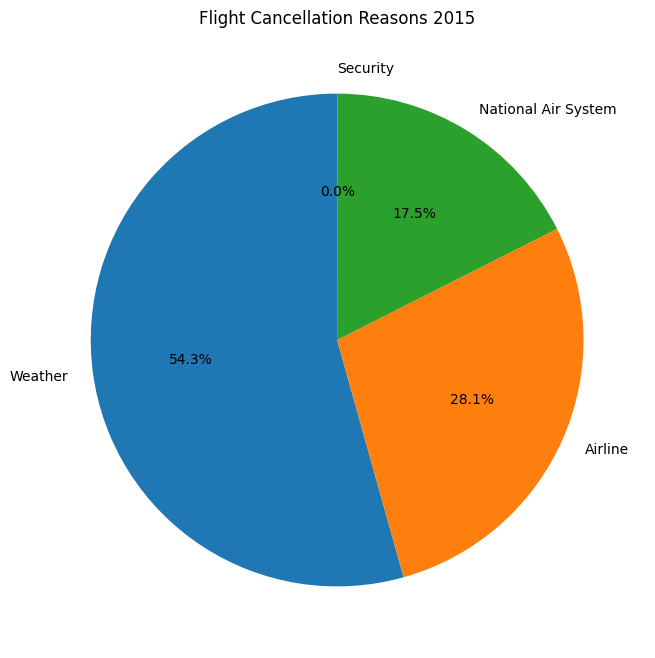

In [35]:
cancellations.index = ['Weather', 'Airline', 'National Air System', 'Security']

cancellations.plot(kind='pie', figsize=(8, 8), autopct='%1.1f%%', startangle=90)

plt.title('Flight Cancellation Reasons 2015')
plt.ylabel('')
plt.show()

### Key Insight
Weather is responsible for over 54% of all flight cancellations in 2015, making it 
by far the leading cause. Security related cancellations are extremely rare at 0%.